# DQN with Target Network CartPole Balancer

Deep Q-Networks (DQN) use neural networks to approximate Q-values. Standard DQN updates can diverge due to moving targets. Introducing a **Target Network** ($\theta^-$)—which is copy-synchronized to the primary policy network ($\theta$) periodically—stabilizes predictions during gradients backpropagation. This notebook implements DQN in PyTorch on a self-contained physics environment.



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import deque

# Custom Physics Simulator for CartPole (Simplified State Dimensions)
class SimpleCartPole:
    def __init__(self):
        self.reset()
        
    def reset(self):
        self.state = np.array([0.0, 0.0, 0.05 * np.random.uniform(-1, 1), 0.0], dtype=np.float32)
        self.steps = 0
        return self.state
        
    def step(self, action):
        self.steps += 1
        x, x_dot, theta, theta_dot = self.state
        
        force = 10.0 if action == 1 else -10.0
        g = 9.8
        m_c = 1.0
        m_p = 0.1
        length = 0.5
        
        temp = (force + m_p * length * theta_dot**2 * np.sin(theta)) / (m_c + m_p)
        theta_acc = (g * np.sin(theta) - np.cos(theta) * temp) / (length * (4.0/3.0 - m_p * np.cos(theta)**2 / (m_c + m_p)))
        x_acc = temp - m_p * length * theta_acc * np.cos(theta) / (m_c + m_p)
        
        dt = 0.02
        x += dt * x_dot
        x_dot += dt * x_acc
        theta += dt * theta_dot
        theta_dot += dt * theta_acc
        
        self.state = np.array([x, x_dot, theta, theta_dot], dtype=np.float32)
        
        done = False
        if abs(x) > 2.4 or abs(theta) > 0.209 or self.steps >= 200:
            done = True
            
        reward = 1.0
        return self.state, reward, done

env = SimpleCartPole()



## DQN Model and Replay Buffer

We define our Q-network layers and implement a cyclic **Replay Buffer** to store and sample random transitions, breaking sequential dependencies.



In [2]:
class QNetwork(nn.Module):
    def __init__(self, state_dim=4, action_dim=2):
        super(QNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 32),
            nn.ReLU(),
            nn.Linear(32, action_dim)
        )
    def forward(self, x):
        return self.net(x)

class ReplayBuffer:
    def __init__(self, capacity=1000):
        self.buffer = deque(maxlen=capacity)
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (torch.FloatTensor(np.array(states)), 
                torch.LongTensor(actions), 
                torch.FloatTensor(rewards), 
                torch.FloatTensor(np.array(next_states)), 
                torch.FloatTensor(dones))
    def __len__(self):
        return len(self.buffer)

# Initialize networks
policy_net = QNetwork()
target_net = QNetwork()
target_net.load_state_dict(policy_net.state_dict()) # Synchronize networks
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=0.01)
memory = ReplayBuffer(capacity=1000)



## Target Network DQN Gradient Updates Loop

We train our models for 100 episodes. We update policy network gradients using MSE loss and periodically copy policy weights to the target network.



In [3]:
# Hyperparameters
gamma = 0.99
epsilon = 0.7
epsilon_decay = 0.96
min_epsilon = 0.05
batch_size = 64
target_update_frequency = 10 # Synchronize target network every 10 episodes

episode_rewards = []

print("Training DQN Agent with Target Network updates...")
for ep in range(1, 101):
    state = env.reset()
    total_reward = 0
    done = False
    
    while not done:
        # Epsilon-greedy
        if np.random.rand() < epsilon:
            action = np.random.randint(0, 2)
        else:
            state_t = torch.FloatTensor(state)
            with torch.no_grad():
                action = torch.argmax(policy_net(state_t)).item()
                
        next_state, reward, done = env.step(action)
        memory.push(state, action, reward, next_state, done)
        
        state = next_state
        total_reward += reward
        
        # Perform optimizer step if memory holds enough samples
        if len(memory) >= batch_size:
            states, actions, rewards, next_states, dones = memory.sample(batch_size)
            
            # Current Q-values
            q_values = policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
            
            # Target Q-values using Target Network (detaching gradients)
            with torch.no_grad():
                max_next_q = target_net(next_states).max(1)[0]
                expected_q = rewards + gamma * max_next_q * (1.0 - dones)
                
            loss = nn.functional.mse_loss(q_values, expected_q)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
    episode_rewards.append(total_reward)
    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    
    # Synchronize target network weights
    if ep % target_update_frequency == 0:
        target_net.load_state_dict(policy_net.state_dict())
        
    if ep % 20 == 0:
        avg_reward = np.mean(episode_rewards[-20:])
        print(f"Episode {ep:3d}/100 | Epsilon: {epsilon:.2f} | Average Reward (last 20): {avg_reward:.2f}")



Training DQN Agent with Target Network updates...
Episode  20/100 | Epsilon: 0.31 | Average Reward (last 20): 17.20
Episode  40/100 | Epsilon: 0.14 | Average Reward (last 20): 12.45
Episode  60/100 | Epsilon: 0.06 | Average Reward (last 20): 44.95
Episode  80/100 | Epsilon: 0.05 | Average Reward (last 20): 106.15
Episode 100/100 | Epsilon: 0.05 | Average Reward (last 20): 151.70


## Cumulative Rewards Plot

We plot the steps balanced per episode across training runs to evaluate DQN performance and target network convergence.



<cell>:13: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



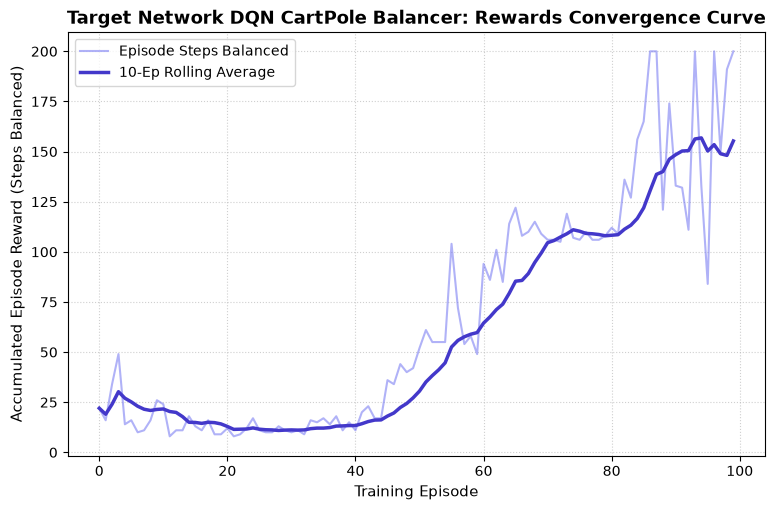

In [4]:
plt.figure(figsize=(9, 5.5))
plt.plot(episode_rewards, label='Episode Steps Balanced', color='#6366F1', alpha=0.5)

# Rolling average overlay
rolling_rewards = [np.mean(episode_rewards[max(0, i-10):i+1]) for i in range(len(episode_rewards))]
plt.plot(rolling_rewards, label='10-Ep Rolling Average', color='#4338CA', linewidth=2.5)

plt.title('Target Network DQN CartPole Balancer: Rewards Convergence Curve', fontsize=13, fontweight='bold')
plt.xlabel('Training Episode', fontsize=11)
plt.ylabel('Accumulated Episode Reward (Steps Balanced)', fontsize=11)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
